# Formula 1 2025 Season Summary

### 1. Season Summary for Each Driver

Here, I used `plotly` for an interactive graph

1. Heatmap for each driver's result for each round
2. Final total points

In [2]:
import fastf1 as ff1

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.io import show
from plotly.subplots import make_subplots

from utility import set_dark

ff1.Cache.enable_cache('./data/cache')

In [3]:
season = 2025
schedule = ff1.get_event_schedule(season, include_testing=False)

schedule.head()

,RoundNumber,Country,Location,OfficialEventName,EventDate,EventName,EventFormat,Session1,Session1Date,Session1DateUtc,...,Session3,Session3Date,Session3DateUtc,Session4,Session4Date,Session4DateUtc,Session5,Session5Date,Session5DateUtc,F1ApiSupport
1,1,Australia,Melbourne,FORMULA 1 LOUIS VUITTON AUSTRALIAN GRAND PRIX ...,2025-03-16,Australian Grand Prix,conventional,Practice 1,2025-03-14 12:30:00+11:00,2025-03-14 01:30:00,...,Practice 3,2025-03-15 12:30:00+11:00,2025-03-15 01:30:00,Qualifying,2025-03-15 16:00:00+11:00,2025-03-15 05:00:00,Race,2025-03-16 15:00:00+11:00,2025-03-16 04:00:00,True
2,2,China,Shanghai,FORMULA 1 HEINEKEN CHINESE GRAND PRIX 2025,2025-03-23,Chinese Grand Prix,sprint_qualifying,Practice 1,2025-03-21 11:30:00+08:00,2025-03-21 03:30:00,...,Sprint,2025-03-22 11:00:00+08:00,2025-03-22 03:00:00,Qualifying,2025-03-22 15:00:00+08:00,2025-03-22 07:00:00,Race,2025-03-23 15:00:00+08:00,2025-03-23 07:00:00,True
3,3,Japan,Suzuka,FORMULA 1 LENOVO JAPANESE GRAND PRIX 2025,2025-04-06,Japanese Grand Prix,conventional,Practice 1,2025-04-04 11:30:00+09:00,2025-04-04 02:30:00,...,Practice 3,2025-04-05 11:30:00+09:00,2025-04-05 02:30:00,Qualifying,2025-04-05 15:00:00+09:00,2025-04-05 06:00:00,Race,2025-04-06 14:00:00+09:00,2025-04-06 05:00:00,True
4,4,Bahrain,Sakhir,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2025,2025-04-13,Bahrain Grand Prix,conventional,Practice 1,2025-04-11 14:30:00+03:00,2025-04-11 11:30:00,...,Practice 3,2025-04-12 15:30:00+03:00,2025-04-12 12:30:00,Qualifying,2025-04-12 19:00:00+03:00,2025-04-12 16:00:00,Race,2025-04-13 18:00:00+03:00,2025-04-13 15:00:00,True
5,5,Saudi Arabia,Jeddah,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2025,2025-04-20,Saudi Arabian Grand Prix,conventional,Practice 1,2025-04-18 16:30:00+03:00,2025-04-18 13:30:00,...,Practice 3,2025-04-19 16:30:00+03:00,2025-04-19 13:30:00,Qualifying,2025-04-19 20:00:00+03:00,2025-04-19 17:00:00,Race,2025-04-20 20:00:00+03:00,2025-04-20 17:00:00,True


In [4]:
# Each driver's standing and points for each race
standings = []
event_names_short = [] # for the heatmap index later

for i, event in schedule.iterrows():
    event_name, round_number = event['EventName'], event['RoundNumber']
    event_names_short.append(event_name.replace("Grand Prix", ""))
    
    # load race data of that specific race
    session_r = ff1.get_session(season, event_name, 'R')
    session_r.load()
    
    # add sprint race points if applicable
    # sprint race is called "sprint_qualifying" for EventFormat
    session_s = None
    if event['EventFormat'] == 'sprint_qualifying':
        session_s = ff1.get_session(season, event_name, 'S')
        session_s.load()
    
    # calculate points for each driver
    for j, driver_row in session_r.results.iterrows():
        abbr, race_points, race_position = driver_row['Abbreviation'], driver_row['Points'], driver_row['Position']
        
        sprint_points = 0
        if session_s is not None:
            driver_row = session_s.results.loc[session_s.results['Abbreviation'] == abbr] # keep rows that match the driver
            if not driver_row.empty:
                sprint_points = driver_row['Points'].values[0]
        
        standings.append({
            'EventName': event_name,
            'RoundNumber': round_number,
            'Driver': abbr,
            'Points': race_points + sprint_points,
            'Position': race_position
        })
    

core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

In [5]:
standings_df = pd.DataFrame(standings)
standings_df.head()

,EventName,RoundNumber,Driver,Points,Position
0,Australian Grand Prix,1,NOR,25.0,1.0
1,Australian Grand Prix,1,VER,18.0,2.0
2,Australian Grand Prix,1,RUS,15.0,3.0
3,Australian Grand Prix,1,ANT,12.0,4.0
4,Australian Grand Prix,1,ALB,10.0,5.0


__standings__ now contains: `EventName`, `RoundNumber`, `Driver`, and `Points`, `Position` for each race.

In [6]:
# drivers as rows, events as columns, use points for values
standings_df2 = standings_df.pivot(index='Driver', columns='RoundNumber', values='Points')
standings_df2.fillna(0)
standings_df2.head()

RoundNumber,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Driver,,,,,,,,,,,,,,,,,,,,,
ALB,10.0,6.0,2.0,0.0,2.0,10.0,10.0,2.0,0.0,0.0,...,10.0,6.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
ALO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,6.0,...,4.0,0.0,0.0,6.0,1.0,0.0,3.0,0.0,8.0,8.0
ANT,12.0,10.0,8.0,0.0,8.0,10.0,0.0,0.0,0.0,15.0,...,0.0,2.0,12.0,10.0,1.0,8.0,25.0,15.0,13.0,0.0
BEA,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,0.0,0.0,2.0,2.0,12.0,8.0,1.0,0.0,0.0
BOR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [7]:
standings_df2['total_points'] = standings_df2.sum(axis=1) # sum of points in row direction
standings_df2.sort_values(by='total_points', ascending=True, inplace=True) 
total_points = standings_df2['total_points'].values # store total_points data
standings_df2.drop(columns=['total_points']) # drop the col

positions = standings_df.pivot(index='Driver', columns='RoundNumber', values='Position').fillna('N/A')

In [8]:
total_points

array([  0.,   0.,  19.,  22.,  33.,  33.,  38.,  38.,  41.,  51.,  51.,
        56.,  64.,  73., 150., 156., 242., 319., 410., 421., 423.])

In [9]:
# hover text for plotly (got help from other materials)

# for each driver, for each round, extract that driver's position
hover_info = [
    [
        {
            'position': positions.at[driver, race]
        } for race in schedule['RoundNumber']
    ] for driver in standings_df2.index # because drivers are row indices
]

In [10]:
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.9, 0.1],
    subplot_titles=('2025 Summary', 'Total Points')
)
fig.update_layout(width=1600,
                  height=800,
                  paper_bgcolor='#222222',
                  font=dict(color='white')
                  )

# first heatmap
fig.add_trace( # add graph to a specific position
    go.Heatmap(
        x=event_names_short, 
        y=standings_df2.index, # drivers
        z=standings_df2.values, # points 
        texttemplate='%{text}', # displays point value on each cell
        text=standings_df2.values,
        customdata=hover_info,
        hovertemplate=(
            "Driver: %{y}<br>"
            "Race Name: %{x}<br>"
            "Points: %{z}<br>"
            "Position: %{customdata.position}<extra></extra>"
        ),
        colorscale='Pubu',
        showscale=False,
        zmin=0, # min color value starts at 0
        zmax=standings_df2.values.max() 
    ),
    row=1,
    col=1
)

# seocnd heatmap
fig.add_trace(
    go.Heatmap(
        x=['Total Points'] * len(total_points),
        y=standings_df2.index,
        z=total_points,
        texttemplate='%{text}',
        text=total_points,
        colorscale='Pubu',
        showscale=False,
        zmin=0,
        zmax=total_points.max()
    ),
    row=1,
    col=2
)

show(fig)

Github does not render `plotly` graph.   
The plot has been saved as `f1_2025_season_summary_plot.png` in the same folder.

## 2. The Championship Battle

Oscar, Lando, and Max remained the contenders of the 2025 championship.  
Examine the line graph to explore each driver's pace. 

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

from utility import set_dark

In [11]:
# create a new DataFrame for cumulative points of 3 drivers

standings_df3 = standings_df2.loc[['NOR', 'VER', 'PIA']]
standings_df3 = standings_df3.cumsum(axis=1)
standings_df3.drop(columns='total_points', inplace=True)
standings_df3

RoundNumber,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Driver,,,,,,,,,,,,,,,,,,,,,
NOR,25.0,44.0,62.0,77.0,89.0,115.0,133.0,158.0,176.0,176.0,...,275.0,293.0,299.0,314.0,332.0,357.0,390.0,390.0,408.0,423.0
VER,18.0,36.0,61.0,69.0,87.0,99.0,124.0,136.0,137.0,155.0,...,205.0,230.0,255.0,273.0,306.0,321.0,341.0,366.0,396.0,421.0
PIA,2.0,34.0,49.0,74.0,99.0,131.0,146.0,161.0,186.0,198.0,...,309.0,324.0,324.0,336.0,346.0,356.0,366.0,366.0,392.0,410.0


In [12]:
# Since I want the graph to be as follows: x-axis: round numbers, y-axis: cum points, and three line plots
# make the dataframe: wide -> long
standings_df3_long = standings_df3.reset_index(names='Driver').melt(id_vars='Driver', var_name='RoundNumber', value_name='points')

# ff1.plotting_get_driver_color() only provides team colors. (not driver-specific)
# thus, hard-coding the color codes.
driver_color = {
    'NOR': '#FF8000',
    'VER': '#121F45',
    'PIA': '#FFFFFF'
}

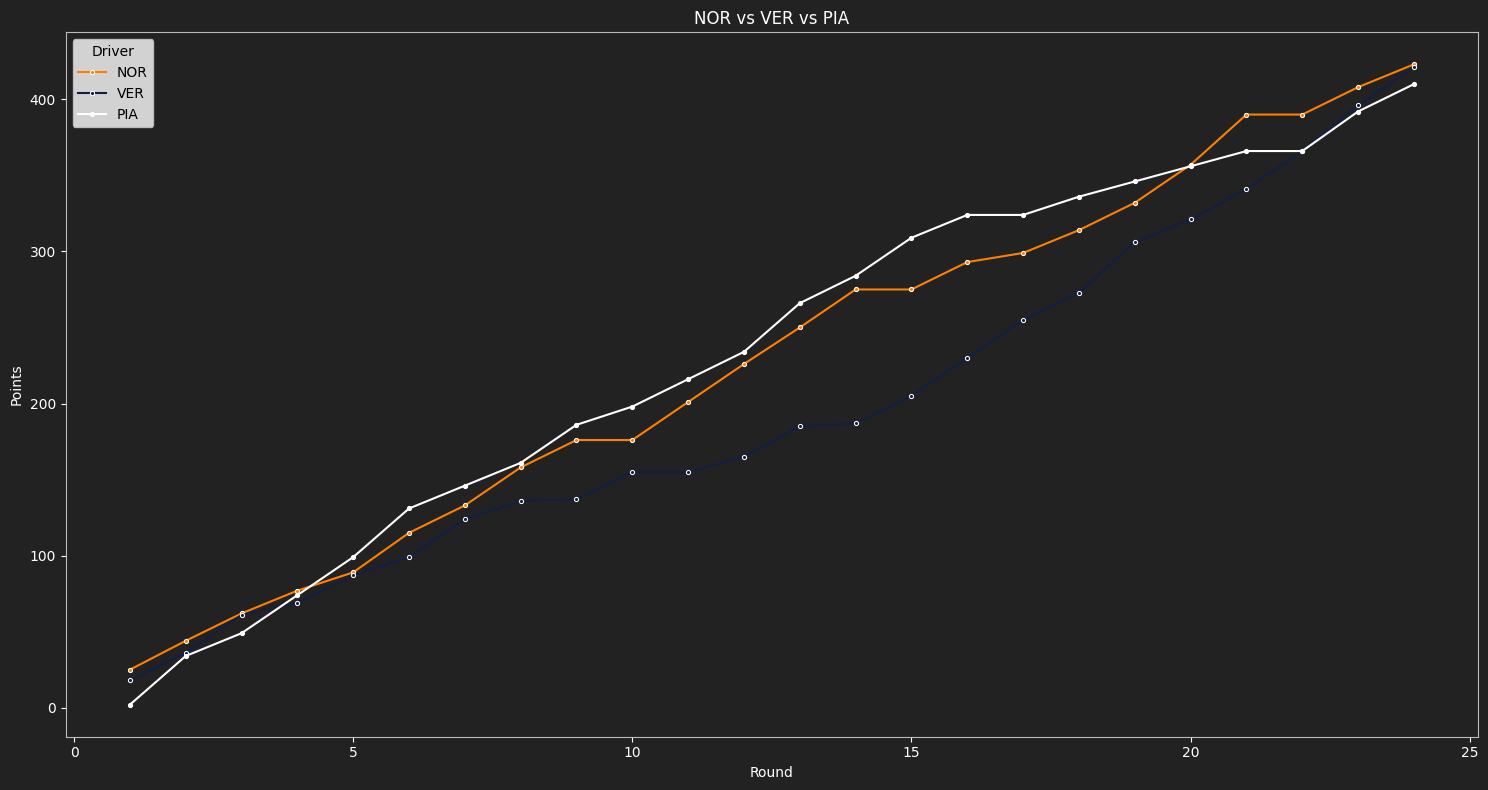

In [13]:
fig, ax = plt.subplots(figsize=(15, 8))
set_dark(ax)

sns.lineplot(data=standings_df3_long, x='RoundNumber', y='points', hue='Driver', marker='.', palette=driver_color)

ax.set_title('NOR vs VER vs PIA')
ax.set_xlabel('Round')
ax.set_ylabel('Points')

plt.tight_layout()
plt.show()

- The gap between **Norris** and **Piastri** closes from Round 16, the Monza GP.
  - In Monza GP 2025, McLaren gave a controversial team order favoring **Norris** to **Piastri**, which awarded second place to **Norris** just because he had a slow pit-stop.
- Notice that at Round 20, the Mexico GP, **Norris** wins his teammate, **Piastri** in the championship battle.
- **Verstappen** quickly catches up to the McLarens since Round 14.
- The championship battle ended with just two points difference between **Norris** and **Verstappen**

## 3. Track-Type Sensitivity

Analyze drivers' performance on each track type
- High-speed, high-downforce, and street circuits
- Wet & Dry  

Circuits were classified by dominant lap-time sensitivity rather than physical layout alone.  
Only representative circuits for each category were included. 

Use functions for reusability

In [14]:
# Categorize the tracks by type
# some tracks might be in multiple categories
event_names_short
track_types = {
    'high_speed': ['Monza', 'Spa-Francorchamps', 'Jeddah', 'Baku', 'Silverstone'],
    'high_downforce': ['Monaco', 'Singapore', 'Hungary', 'Zandvoort', 'Suzuka'],
    'street_circuit': ['Monaco', 'Singapore', 'Baku', 'Jeddah', 'Las Vegas', 'Miami']
}

### 1. Get every race / sprint session 

In [15]:
# to preserve the original dataframe
schedule2 = schedule.copy()

all_results = {}

for i, event in schedule2.iterrows():
  event_name = event['EventName']
  
  all_results[event_name] = {}
  
  # load race session
  session_r = ff1.get_session(season, event_name, 'R')
  session_r.load()
  
  # add to all_results
  all_results[event_name]['race'] = session_r.results.reset_index(drop=True)
    
  # load sprint race session if applicable
  session_s = None
  if event['EventFormat'] == 'sprint_qualifying':
    session_s = ff1.get_session(season, event_name, 'S')
    session_s.load()
    # add to all_results
    all_results[event_name]['sprint'] = session_s.results.reset_index(drop=True)
    
  
  #all_results structure:
  #  {
  #      'Event Name': {
  #          'race': DataFrame,
  #          'sprint': DataFrame (optional)
  #      }
  #  }

core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

### 2. Create a dataframe that contains track category information

In [16]:
# track names
race_mapping = {
    'Bahrain': 'Bahrain',
    'Saudi Arabian': 'Jeddah',
    'Australian': 'Melbourne',
    'Japanese': 'Suzuka',
    'Chinese': 'Shanghai',
    'Miami': 'Miami',
    'Emilia Romagna': 'Imola',
    'Monaco': 'Monaco',
    'Canadian': 'Montreal',
    'Spanish': 'Barcelona',
    'Austrian': 'Red Bull Ring',
    'British': 'Silverstone',
    'Hungarian': 'Hungary',
    'Belgian': 'Spa-Francorchamps',
    'Dutch': 'Zandvoort',
    'Italian': 'Monza',
    'Azerbaijan': 'Baku',
    'Singapore': 'Singapore',
    'United States': 'Austin',
    'Mexico City': 'Mexico City',
    'São Paulo': 'Interlagos',
    'Las Vegas': 'Las Vegas',
    'Qatar': 'Lusail',
    'Abu Dhabi': 'Abu Dhabi'
}

# convert all_results to a dataframe 
def process_results(all_results):
    data = []
  
    def get_track_type(track_name):
        if track_name in track_types['high_speed'] and track_name not in track_types['street_circuit']:
          return 'High Speed'
        elif track_name in track_types['high_downforce'] and track_name not in track_types['street_circuit']:
          return 'High Downforce'
        elif track_name in track_types['street_circuit']:
          return 'Street Circuit'
        else:
          return 'Standard'
        
    def create_df(df, session_type, track_name):
        df = df.copy()
        df['SessionType'] = session_type
        df['TrackName'] = track_name
        df['TrackType'] = get_track_type(track_name)
        df['is_high_speed'] = int(track_name in track_types['high_speed'])
        df['is_high_downforce'] = int(track_name in track_types['high_downforce'])
        df['is_street_circuit'] = int(track_name in track_types['street_circuit'])
        return df
    
    for event_name, sessions in all_results.items():
      track_name = race_mapping.get(event_name.replace(" Grand Prix", ""), event_name)
      
      if 'race' in sessions:
        race_df = create_df(sessions['race'], 'Race', track_name)
        data.append(race_df)
      if 'sprint' in sessions:
        sprint_df = create_df(sessions['sprint'], 'Sprint', track_name)
        data.append(sprint_df)
      
    return pd.concat(data, ignore_index=True)

In [17]:
results_df = process_results(all_results)
results_df.shape # (599, 28)

(599, 28)

In [18]:
print('columns in results_df:')
print(results_df.columns.tolist())

print('=' * 70)

print('session type distributions:')
print(results_df['SessionType'].value_counts())

columns in results_df:
['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps', 'SessionType', 'TrackName', 'TrackType', 'is_high_speed', 'is_high_downforce', 'is_street_circuit']
session type distributions:
SessionType
Race      479
Sprint    120
Name: count, dtype: int64


In [19]:
results_df['Status'].value_counts()

Status
Finished         438
Lapped            89
Retired           63
Disqualified       6
Did not start      3
Name: count, dtype: int64

In [20]:
print('track type distributions:')
results_df.groupby(['TrackName', 'TrackType', 'SessionType']).size().reset_index(name='entries').groupby(['TrackName', 'TrackType'])['entries'].sum().reset_index().sort_values(by='TrackType')

track type distributions:


,TrackName,TrackType,entries
23,Zandvoort,High Downforce,20
5,Hungary,High Downforce,20
22,Suzuka,High Downforce,20
21,Spa-Francorchamps,High Speed,40
19,Silverstone,High Speed,20
16,Monza,High Speed,20
18,Shanghai,Standard,40
17,Red Bull Ring,Standard,20
15,Montreal,Standard,20
12,Mexico City,Standard,20


### 3. Performance Assessment

In [21]:
# calculate performance
df = results_df.copy()

metrics = []

for driver in df['Abbreviation'].unique():
    driver_data = df[df['Abbreviation'] == driver]
    
    for track_type in ['High Speed', 'High Downforce', 'Street Circuit','Standard']: 
        track_data = driver_data[driver_data['TrackType'] == track_type]
        # skip if no data for that track 
        if len(track_data) == 0:
          continue 
        
        race_data = track_data[track_data['SessionType'] == 'Race'] # or use .loc[] ?
        sprint_data = track_data[track_data['SessionType'] == 'Sprint']
        
        # handle position & grid position column (dtype: float64)
        # grid position is the starting pos. 
        positions = []
        grid_positions = [] 
        positions_gained_list = [] # grid position - position
        for _, row in track_data.iterrows():
            positions.append(row['Position'])
            grid_positions.append(row['GridPosition'])
            positions_gained_list.append(row['GridPosition'] - row['Position'])
        
        avg_position = np.mean(positions)
        avg_grid_position = np.mean(grid_positions) 
        positions_gained = np.mean(positions_gained_list)
        
        total_points = track_data['Points'].sum()
        total_sessions = track_data.shape[0]
        points_per_session = total_points / total_sessions if total_sessions > 0 else 0
        
        # consistency calculation using standard deviation
        position_std = np.std(positions) if len(positions) > 1 else 0
        
        # dnf count
        dnf_count = 0
        for status in track_data['Status']:
            if status != 'Finished' and status != 'Lapped':
                dnf_count += 1
        dnf_rate = dnf_count / total_sessions if total_sessions > 0 else 0
        
        # finished_count
        finished_count = len(track_data) - dnf_count
        finished_rate = finished_count / total_sessions if total_sessions > 0 else 0
        
        metrics.append({
          'Driver': driver,
          'TrackType': track_type,
          'TotalSessions': total_sessions,
          'RaceSessions': len(race_data),
          'SprintSessions': len(sprint_data),
          'AvgGridPosition': avg_grid_position,
          'AvgPosition': avg_position,
          'AvgPositionsGained': positions_gained,
          'TotalPoints': total_points,
          'PointsPerSession': points_per_session,
          'Consistency': position_std
          'DnfRate': dnf_rate,
          'FinishedRate': finished_rate,
        })

### 4. Driver Heatmap

In [49]:
metrics_df = pd.DataFrame(metrics)

def driver_heatmap(metrics_df, metric='PointsPerSession'):
  metrics_pivot = metrics_df.pivot(index='Driver', columns='TrackType', values=metric)
  
  # sort the data by average perf. in descending order
  metrics_pivot['Average'] = metrics_pivot.mean(axis=1) # average perf. 
  metrics_pivot = metrics_pivot.sort_values('Average', ascending=False) # sort in descending order
  metrics_pivot = metrics_pivot.drop('Average', axis=1) # drop the Average column
  
  # re-order columns
  order = ['High Speed', 'High Downforce', 'Street Circuit', 'Standard']
  metrics_pivot = metrics_pivot[[col for col in order if col in metrics_pivot.columns]]
  
  # for positions related metrics, lower number indicates better performance
  if metric in ['AvgPosition', 'AvgGridPosition']:
    cmap = 'RdYlGn_r' # reversed
  else:
    cmap = 'RdYlGn'
  
  # visualization
  fig, ax = plt.subplots(figsize=(14, 10))
  set_dark(ax)
  
  sns.heatmap(metrics_pivot, annot=True, fmt='.2f', cmap=cmap, cbar_kws={'label': metric}, linewidth=0.5, ax=ax)
  ax.set_title(f"Driver Performance by Track Type: {metric}")
  ax.set_xlabel('Track Type')
  ax.set_ylabel('Driver')
  
  # set the text color of cbar
  cbar = ax.collections[0].colorbar
  cbar.ax.tick_params(color='white', labelcolor='white')
  
  plt.tight_layout()
  return fig

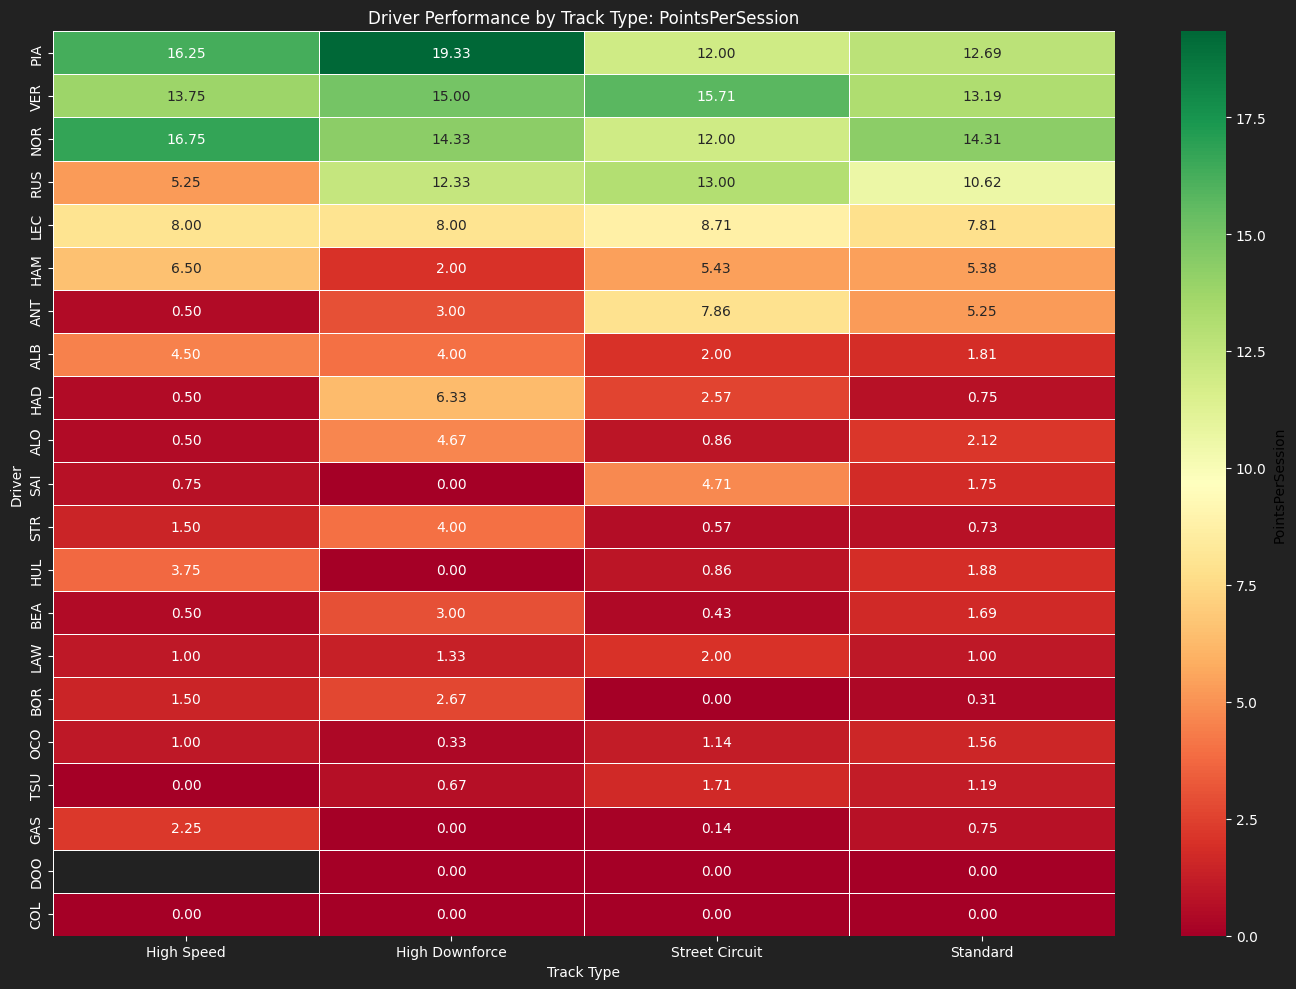

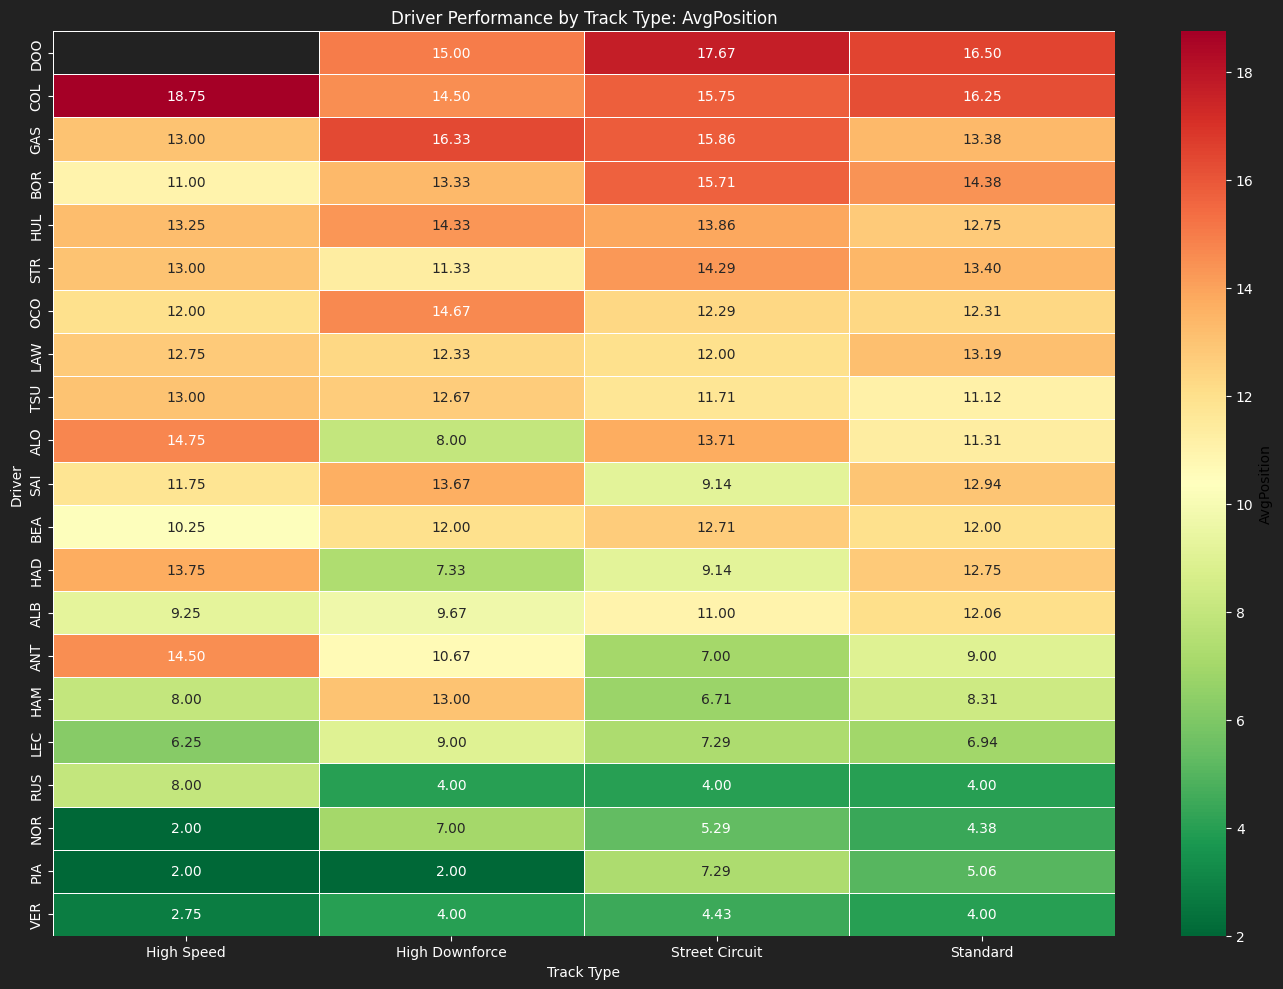

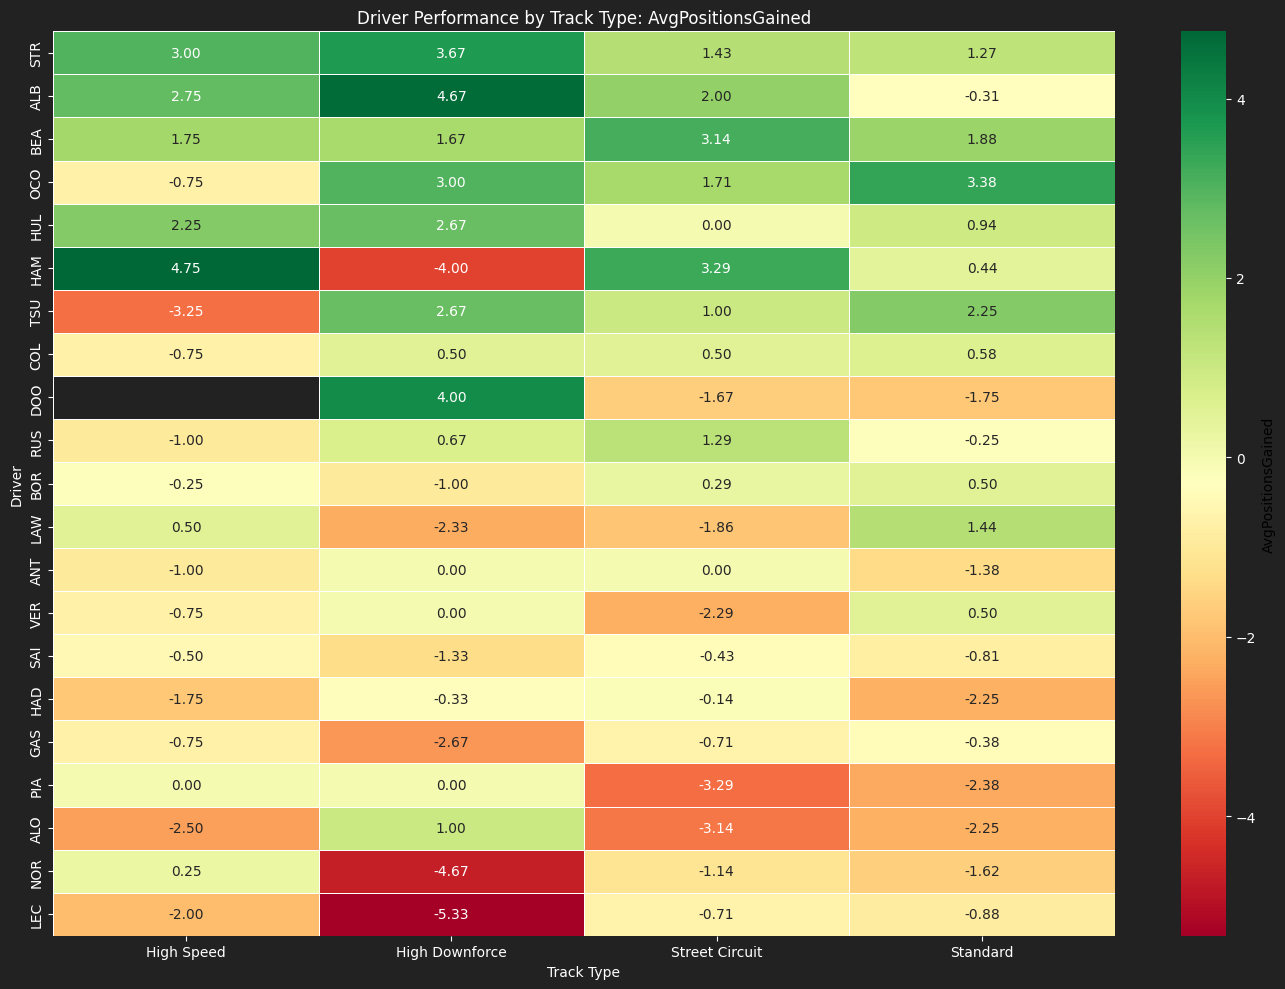

In [51]:
fig1 = driver_heatmap(metrics_df, 'PointsPerSession')

fig2 = driver_heatmap(metrics_df, 'AvgPosition')

fig3 = driver_heatmap(metrics_df, 'AvgPositionsGained')

These plots show the driver performance by  three metrics: `PointsPerSession`, `AveragePosition`, and `AveragePositionGained`. 

### 5. Radar Chart

In [153]:
# since seaborn does not support radar chart (nor does matplotlib)
# I had to construct a radar chart manually

# use polar coord system and convert categories into angles

def radar_charts(metrics_df, drivers):
    n = len(drivers)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 7), subplot_kw={'polar': True})
    
    if n == 1:
        axes = [axes]
    
    for i, abbr in enumerate(drivers):
        ax = axes[i]
        driver_data = metrics_df.loc[metrics_df['Driver'] == abbr]
        # just in case the input is wrong
        if len(driver_data) <= 0:
            raise ValueError(f"No {abbr} in the 2025 Grid")

        track_types_list = driver_data['TrackType'].tolist()
        points_list = driver_data['PointsPerSession'].tolist() # PointsPerSession : points per session for the specific track type
        
        angle = np.linspace(0, 2*np.pi, len(track_types_list), endpoint=False).tolist()
        # to close the circle
        angle += angle[:1] # to concat. list, use [:1] indexing
        points_list += points_list[:1]
        
        set_dark(ax)
        
        ax.set_theta_offset(np.pi / 2) # starting point
        ax.set_theta_direction(-1) # clockwise dir. 
        
        ax.plot(angle, points_list)
        ax.fill(angle, points_list, alpha=0.25)
        
        ax.set_xticks(angle[:-1], track_types_list, fontsize=10)
        ax.tick_params(axis='x', which='major', pad=15)
        
        ax.set_rlabel_position(0)
        ax.set_ylim(0, max(points_list)*1.1)
        ax.set_ylabel('') # removed y label for simplicity
        ax.set_yticklabels([])
        
        ax.grid(linewidth=0.5, alpha=0.2)
        
        # add values to the plot
        for ang, val, track_type in zip(angle, points_list, track_types_list):
            ax.text(ang, val * 0.85, f"{val:.2f}", ha='center', va='center', size=10, color='white')
        
        ax.set_title(f"{abbr} - Track Type Performance", x=-0.2, y=1.2, ha='left')
    
    plt.tight_layout()
    return fig

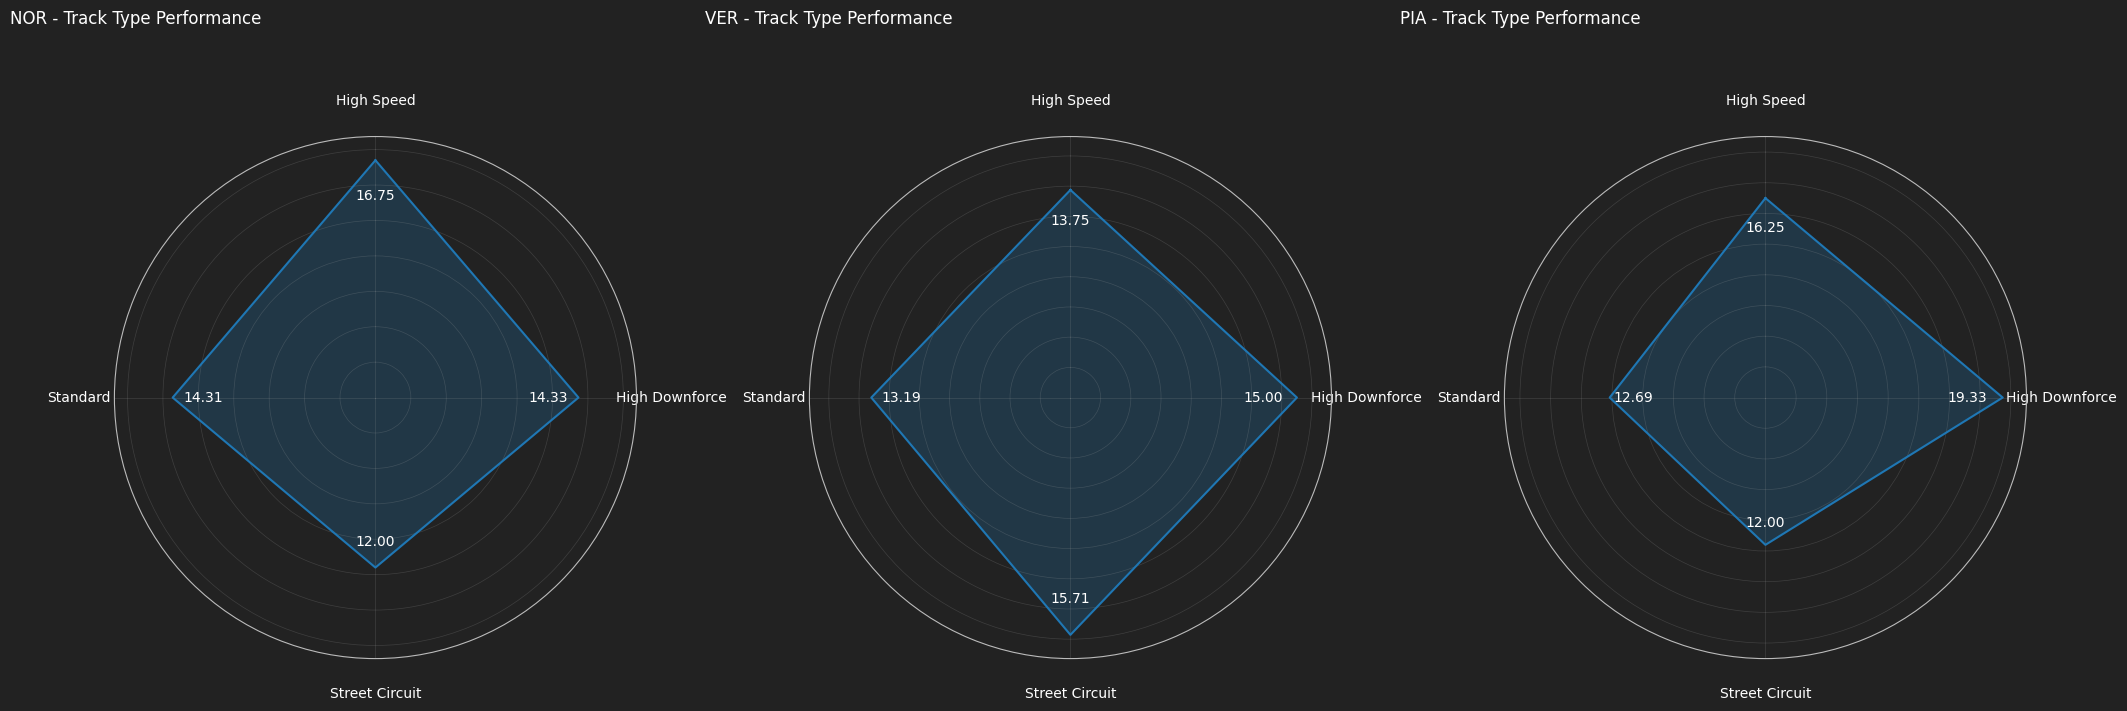

In [155]:
fig_radar = radar_charts(metrics_df, ['NOR', 'VER', 'PIA'])

The radar chart shows `points_per_race(session)` for each track category.
- __VER__ shows the best consistency across all track categories among the three championship contenders. 
- __NOR__ performed the best in High Speed tracks, while __PIA__ showed a strong performance in tracks that require downforce. 

The function is reusable to compare different drivers.

## Summary

- The 2025 season featured an intense championship battle among __Norris__, __Verstappen__, and __Piastri__. At the beginning, it was a battle between the McLaren drivers, but __Verstappen__ dramatically joined the battle after the summer break.
- __Norris__ clinched the title with just 2-points margin over Verstappen, despite Max's win in Abu Dhabi. 
- With some controversial team orders within McLaren favoring __Norris__, __Piastri__ lost his momentum in the title fight.

<br>

- Driver Performance Analysis reveals dinstinct strengths acrosss track types. 
- The interactive visualizations, such as heatmaps, line plots, and radar charts, provided detailed and easily recognizable insights. 
- The functions used for analyses are re-usable for future usage. 